# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [ ]:
# Your comment here
"""
I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects 
my understanding of the material.

Sarah Jauregui
"""

## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [3]:
# Your code here 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [4]:
# Your code here
g=9.81 #m/s^2
L=1 #m

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [9]:
# Your code here
def pendulum(t,y):
    theta,omega=y #y[0]=theta y[1]=omega
    dthetadt=omega
    domegadt=-(g/L)*np.sin(theta)
    return [dthetadt,domegadt]
    

Give you equation some initial conditions. Run the cell below.

In [6]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity

Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [7]:
# Your code here
t_span=(0,10)
e_val=np.linspace(0,10,500) #0 to 10 with 500 intervals
sol=solve_ivp(pendulum, t_span, [theta_0,omega_0], t_eval=e_val)

Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [16]:
# Your code here
theta_values=sol.y[0]
time_values=sol.t

#print(theta_values)
#print(time_values)

Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [26]:
# Your code here
T_theory=2*np.pi*np.sqrt(L/g)

Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [30]:
# Your code here
print(f"Theoretical Period: {T_theory:.2g}s")

Theoretical Period: 2s


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [17]:
zero_crossings = np.where(np.diff(np.sign(theta_values)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_values[zero_crossings[1]] - time_values[zero_crossings[0]])
else:
    T_numerical = None

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

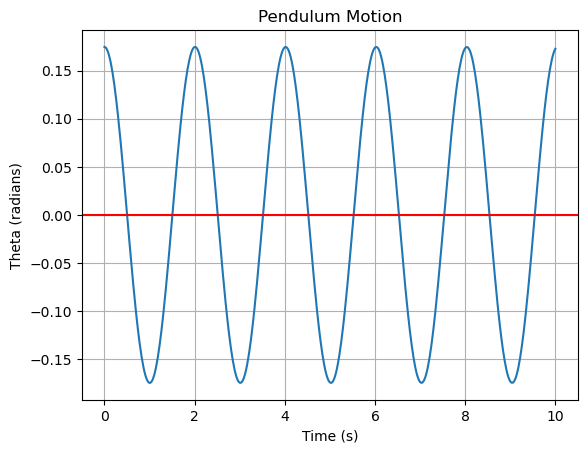

In [23]:
# Your code here
plt.plot(time_values,theta_values)
plt.axhline(0, color='red')
plt.xlabel("Time (s)")
plt.ylabel("Theta (radians)")
plt.title("Pendulum Motion")
plt.grid(True)

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [31]:
# Your code here
print(f"Numerical Period:{T_numerical:.4g} s")

Numerical Period:2.004 s


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [ ]:
# Your comment here
"""
The approximation is relatively accurate considering it is 2s while the actual is 2.004 
seconds
"""

## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [2]:
# Your code here
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [40]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [19]:
# Your code here
df=pd.read_csv("owid-covid-data.csv")
#print(df)
#print(df["continent"])


Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [23]:
# Your code here
df_country=df[df['location']=='United States']
#print(df_country)

From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [30]:
# Your code here
df_data=df_country[['date','total_cases']].dropna()
#print(df_data.head())
df_data['days_since_start']=range(len(df_country))
#print(df_data.head())
#print(df_data)

Print the first few rows of your `df_country` dataframe.

In [33]:
# Your code here
print(df_country.head())

       iso_code      continent       location        date  total_cases  \
403451      USA  North America  United States  2020-01-05          0.0   
403452      USA  North America  United States  2020-01-06          0.0   
403453      USA  North America  United States  2020-01-07          0.0   
403454      USA  North America  United States  2020-01-08          0.0   
403455      USA  North America  United States  2020-01-09          0.0   

        new_cases  new_cases_smoothed  total_deaths  new_deaths  \
403451        0.0                 NaN           0.0         0.0   
403452        0.0                 NaN           0.0         0.0   
403453        0.0                 NaN           0.0         0.0   
403454        0.0                 NaN           0.0         0.0   
403455        0.0                 NaN           0.0         0.0   

        new_deaths_smoothed  ...  male_smokers  handwashing_facilities  \
403451                  NaN  ...          24.6                     NaN   
4034

In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [44]:
# Your code here
from scipy.optimize import curve_fit
import numpy as np

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [41]:
# Your code here
def exponential_growth(t,C_0,r):
    return C_0*np.exp(r*t)

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [45]:
# Your code here
days = df_data["days_since_start"][:30].values
cases = df_data["total_cases"][:30].values
print(days)
print(cases)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 7. 7. 7.
 7. 7. 7. 7. 9. 9.]


With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [46]:
# Your code here
para,cov=curve_fit(exponential_growth, days, cases, p0=[1,0.1])

Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [50]:
# Your code here
C_0_fit, r_fit = para

Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [52]:
# Your code here
print(f"C_0={C_0_fit:.4f}")
print(f"r={r_fit:.4f}")

C_0=0.1239
r=0.1538


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [56]:
# Your code here
future_days=np.arange(0,60)

Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [57]:
# Your code here 
predicted_cases=exponential_growth(future_days, *para)

**Scater** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

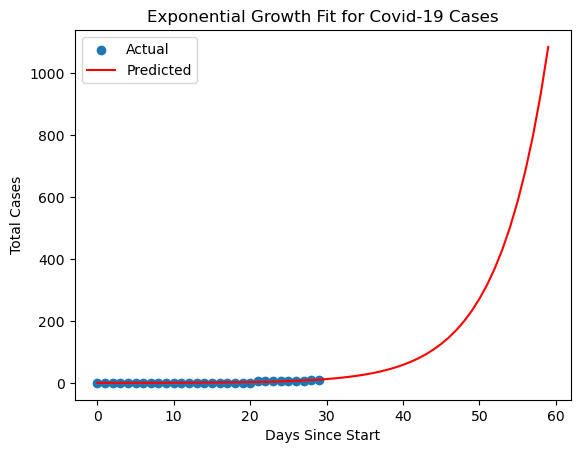

In [61]:
# Your code here
import matplotlib.pyplot as plt
plt.scatter(days,cases,label='Actual')
plt.plot(future_days,predicted_cases,color='red',label="Predicted")
plt.xlabel("Days Since Start")
plt.ylabel("Total Cases")
plt.title("Exponential Growth Fit for Covid-19 Cases")
plt.legend()

How well does your exponential model fit the actual COVID-19 data? 

In [ ]:
# Your comment here
"""
It fits it very well, the predicted line is in line with the actual data
"""

Make another plot but this time to **90 days**.

Text(0.5, 1.0, 'Exponential Growth Fit of Covid-19 Cases (90-Day Prediction)')

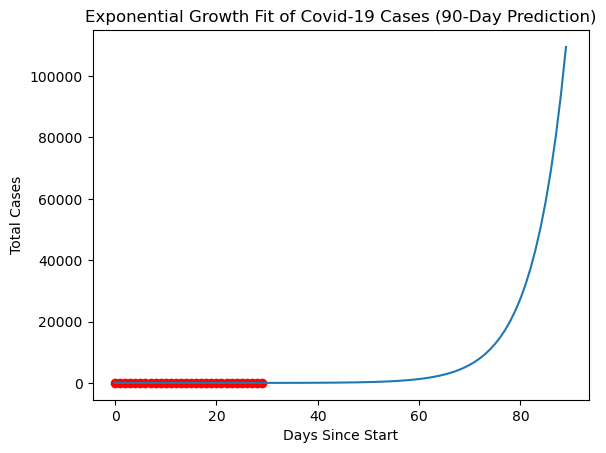

In [62]:
# Your code here
future_days_90 = np.arange(0, 90)
predicted_cases_90 = exponential_growth(future_days_90, *para)
plt.scatter(days, cases, color='red', label='Actual Cases')
plt.plot(future_days_90, predicted_cases_90, label='Predicted Cases (90 days)')
plt.xlabel("Days Since Start")
plt.ylabel("Total Cases")
plt.title("Exponential Growth Fit of Covid-19 Cases (90-Day Prediction)")

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [71]:
# Your code here
print(f"My model predicts {exponential_growth(87,*para):.0f} cases after 87 days")

My model predicts 80497 cases after 87 days


## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

<function matplotlib.pyplot.show(close=None, block=None)>

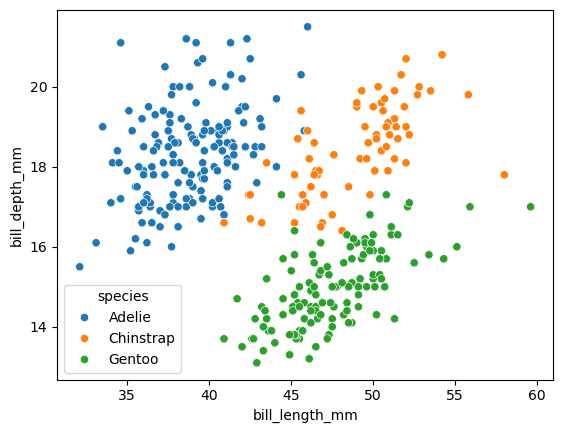

In [81]:
# Your code here
import seaborn as sns
df2=sns.load_dataset("penguins")
#print(df2.head())
sns.scatterplot(x="bill_length_mm",y="bill_depth_mm",hue="species",data=df2)
plt.show


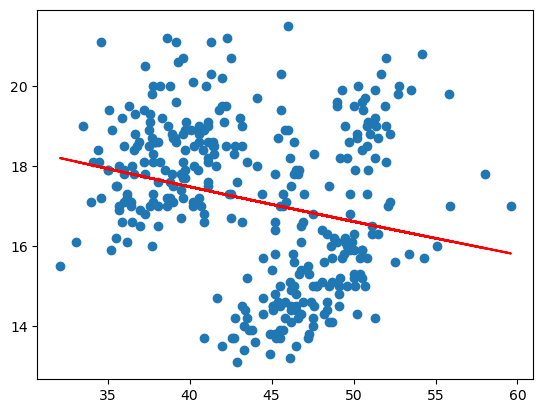

In [83]:
xdata=df2["bill_length_mm"].dropna()
ydata=df2["bill_depth_mm"].dropna()
def exp_model(x,a,b):
    return a*np.exp(b*x)
param,cova=curve_fit(exp_model,xdata,ydata,p0=[1,0.1])
a_fit,b_fit=param
y_fit=exp_model(xdata,a_fit,b_fit)
plt.scatter(xdata,ydata,label="actual")
plt.plot(xdata,y_fit,color='red',label="model")

#i know its not a good fit...

On it's own branch, submit this notebook to Gradescope! 